BGO-14 Transmission Systematics with Re-seating- Longitudinal

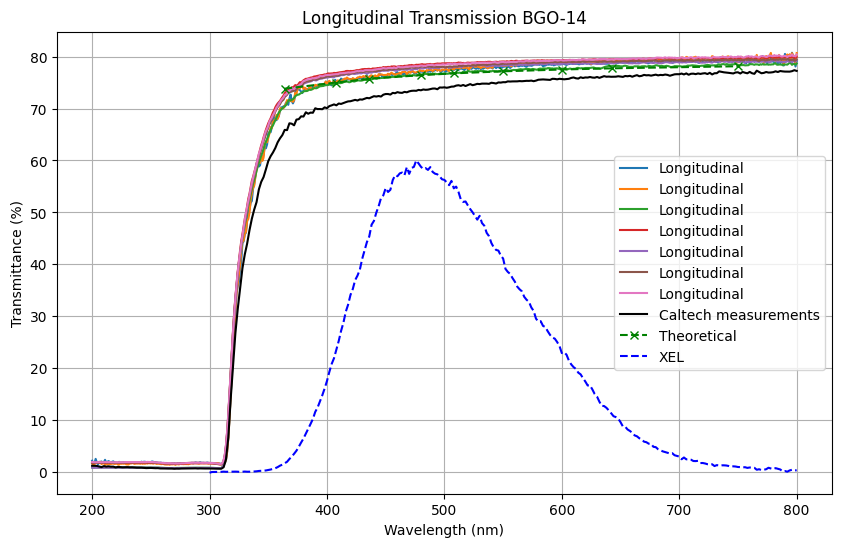

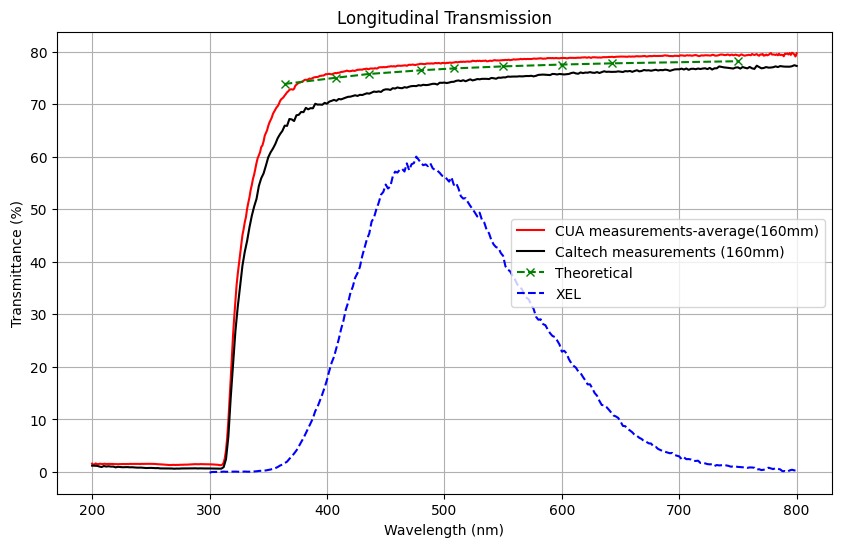

Mean T480 = 77.651
Std Dev = 0.695
SEM = 0.263
CV = 0.90%


In [112]:
#IMPORT PACKAGES
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import pandas as pd
plt.figure(figsize=(10, 6))
#from scipy.signal import find_peaks

Samples_L = [20,21,32,54,38,55,60]
# BGO_14_L = [20,21,32,54]
label_14 = ["Longitudinal", "Longitudinal", "Longitudinal", "Longitudinal", "Longitudinal", "Longitudinal", "Longitudinal"]
BGO_7 = [24,25,26,27]
label_7 = ["Longitudinal", "Longitudinal", "Transverse", "Transverse"]
label_L = ["BGO-14", "BGO-14", "BGO-7", "BGO-7"]
Samples_T = [22,23,26,27]
label_T = ["BGO-14", "BGO-14", "BGO-7", "BGO-7"]
Tper_L = list(Samples_L)#['1', '2', '3', '4', '5', '6', '7', '8'] #LONGITUDINAL TRANSMISSION PERCENTAGE 
Tper_T = list(Samples_T)#['1', '2', '3','4', '5', '6', '7', '8'] #TRANSVERSE TRANSMISSION PERCENTAGE
Tper_L_at = list(Samples_L)#['1', '2', '3','4', '5', '6', '7', '8']#, '7', '8', '9'] 
Tper_L_at_N =list(Samples_L)# ['1', '2', '3','4', '5', '6', '7', '8']
Tper_T_at = list(Samples_T)#['1', '2', '3','4', '5', '6', '7', '8']
AtLen = list(Samples_T )#['1', '2', '3','4', '5', '6', '7', '8']
#CALTECH readings
#####
lam = [200.0, 202.0, 204.0, 206.0, 208.0, 210.0, 212.0, 214.0, 216.0, 218.0, 220.0, 222.0, 224.0, 226.0, 228.0, 230.0, 232.0, 234.0, 236.0, 238.0, 240.0, 242.0, 244.0, 246.0, 248.0, 250.0, 252.0, 254.0, 256.0, 258.0, 260.0, 262.0, 264.0, 266.0, 268.0, 270.0, 272.0, 274.0, 276.0, 278.0, 280.0, 282.0, 284.0, 286.0, 288.0, 290.0, 292.0, 294.0, 296.0, 298.0, 300.0, 302.0, 304.0, 306.0, 308.0, 310.0, 312.0, 314.0, 316.0, 318.0, 320.0, 322.0, 324.0, 326.0, 328.0, 330.0, 332.0, 334.0, 336.0, 338.0, 340.0, 342.0, 344.0, 346.0, 348.0, 350.0, 352.0, 354.0, 356.0, 358.0, 360.0, 362.0, 364.0, 366.0, 368.0, 370.0, 372.0, 374.0, 376.0, 378.0, 380.0, 382.0, 384.0, 386.0, 388.0, 390.0, 392.0, 394.0, 396.0, 398.0, 400.0, 402.0, 404.0, 406.0, 408.0, 410.0, 412.0, 414.0, 416.0, 418.0, 420.0, 422.0, 424.0, 426.0, 428.0, 430.0, 432.0, 434.0, 436.0, 438.0, 440.0, 442.0, 444.0, 446.0, 448.0, 450.0, 452.0, 454.0, 456.0, 458.0, 460.0, 462.0, 464.0, 466.0, 468.0, 470.0, 472.0, 474.0, 476.0, 478.0, 480.0, 482.0, 484.0, 486.0, 488.0, 490.0, 492.0, 494.0, 496.0, 498.0, 500.0, 502.0, 504.0, 506.0, 508.0, 510.0, 512.0, 514.0, 516.0, 518.0, 520.0, 522.0, 524.0, 526.0, 528.0, 530.0, 532.0, 534.0, 536.0, 538.0, 540.0, 542.0, 544.0, 546.0, 548.0, 550.0, 552.0, 554.0, 556.0, 558.0, 560.0, 562.0, 564.0, 566.0, 568.0, 570.0, 572.0, 574.0, 576.0, 578.0, 580.0, 582.0, 584.0, 586.0, 588.0, 590.0, 592.0, 594.0, 596.0, 598.0, 600.0, 602.0, 604.0, 606.0, 608.0, 610.0, 612.0, 614.0, 616.0, 618.0, 620.0, 622.0, 624.0, 626.0, 628.0, 630.0, 632.0, 634.0, 636.0, 638.0, 640.0, 642.0, 644.0, 646.0, 648.0, 650.0, 652.0, 654.0, 656.0, 658.0, 660.0, 662.0, 664.0, 666.0, 668.0, 670.0, 672.0, 674.0, 676.0, 678.0, 680.0, 682.0, 684.0, 686.0, 688.0, 690.0, 692.0, 694.0, 696.0, 698.0, 700.0, 702.0, 704.0, 706.0, 708.0, 710.0, 712.0, 714.0, 716.0, 718.0, 720.0, 722.0, 724.0, 726.0, 728.0, 730.0, 732.0, 734.0, 736.0, 738.0, 740.0, 742.0, 744.0, 746.0, 748.0, 750.0, 752.0, 754.0, 756.0, 758.0, 760.0, 762.0, 764.0, 766.0, 768.0, 770.0, 772.0, 774.0, 776.0, 778.0, 780.0, 782.0, 784.0, 786.0, 788.0, 790.0, 792.0, 794.0, 796.0, 798.0, 800.0]
Tper_L_14 = [1.21, 1.18, 1.17001, 1.06001, 0.940002, 1.13, 1.03001, 1.09001, 1.02, 1.03001, 0.880005, 0.980011, 0.940002, 0.900009, 0.920013, 0.930008, 0.890015, 0.900009, 0.87001, 0.830002, 0.840011, 0.830002, 0.790008, 0.750015, 0.770004, 0.780014, 0.750015, 0.730011, 0.740005, 0.680008, 0.680008, 0.680008, 0.670013, 0.670013, 0.660004, 0.62001, 0.650009, 0.640015, 0.670013, 0.670013, 0.680008, 0.690002, 0.680008, 0.690002, 0.700012, 0.670013, 0.690002, 0.670013, 0.670013, 0.680008, 0.670013, 0.670013, 0.650009, 0.640015, 0.630005, 0.630005, 0.920013, 2.44, 6.67001, 14.08, 20.56, 26.74, 31.4, 35.37, 39.24, 41.9, 43.98, 46.56, 48.76, 50.52, 51.96, 54.43, 55.88, 56.8, 58.3, 59.88, 60.82, 61.54, 62.4, 63.5, 64.27, 64.89, 65.89, 65.85, 67.16, 67.08, 66.77, 67.87, 67.96, 68.5, 68.46, 69.28, 69.0, 69.22, 69.19, 70.05, 69.9, 69.91, 69.87, 70.23, 70.07, 70.47, 70.62, 70.8, 70.62, 70.97, 70.89, 71.07, 71.23, 71.38, 71.41, 71.53, 71.67, 71.55, 71.76, 71.72, 71.89, 72.05, 71.98, 72.18, 72.38, 72.31, 72.41, 72.31, 72.67, 72.8, 72.8, 72.69, 73.02, 72.95, 73.16, 73.05, 73.02, 73.21, 73.13, 73.31, 73.41, 73.44, 73.42, 73.59, 73.52, 73.67, 73.61, 73.64, 73.74, 73.85, 73.86, 73.72, 74.06, 74.04, 74.09, 74.0, 74.09, 74.22, 74.24, 74.42, 74.49, 74.37, 74.54, 74.34, 74.53, 74.71, 74.5, 74.61, 74.76, 74.71, 74.8, 74.81, 74.8, 74.76, 74.97, 74.91, 74.82, 75.03, 75.0, 75.08, 75.07, 75.23, 75.2, 75.23, 75.23, 75.24, 75.29, 75.26, 75.3, 75.34, 75.33, 75.38, 75.27, 75.38, 75.55, 75.58, 75.61, 75.57, 75.55, 75.52, 75.73, 75.71, 75.63, 75.73, 75.67, 75.63, 75.68, 75.73, 75.9, 75.99, 75.83, 75.77, 76.02, 75.89, 75.99, 75.97, 76.08, 75.97, 75.94, 76.08, 75.91, 76.07, 76.24, 76.13, 76.16, 76.12, 76.13, 76.14, 76.22, 76.16, 76.1, 76.27, 76.22, 76.3, 76.13, 76.3, 76.43, 76.22, 76.3, 76.48, 76.4, 76.43, 76.34, 76.43, 76.53, 76.39, 76.48, 76.44, 76.55, 76.48, 76.32, 76.45, 76.59, 76.62, 76.61, 76.74, 76.57, 76.77, 76.51, 76.7, 76.72, 76.63, 76.76, 76.67, 76.76, 76.81, 76.65, 76.88, 76.57, 76.8, 76.81, 77.16, 77.06, 76.98, 76.92, 76.88, 76.83, 76.76, 76.95, 76.98, 76.75, 77.05, 76.9, 76.79, 77.06, 76.8, 76.69, 77.3, 77.04, 76.8, 76.87, 77.04, 76.93, 76.95, 77.01, 77.17, 77.04, 77.23, 77.16, 77.12, 77.11, 77.11, 77.2, 77.39, 77.25]
Tper_T_14 = [0.86, 1.06001, 0.500015, 0.790008, 0.920013, 0.830002, 0.970001, 0.900009, 0.880005, 0.800003, 0.800003, 0.730011, 0.770004, 0.770004, 0.720001, 0.780014, 0.76001, 0.76001, 0.740005, 0.690002, 0.670013, 0.690002, 0.660004, 0.680008, 0.670013, 0.650009, 0.660004, 0.630005, 0.640015, 0.61, 0.630005, 0.580002, 0.630005, 0.600006, 0.590011, 0.580002, 0.590011, 0.570007, 0.570007, 0.62001, 0.62001, 0.62001, 0.600006, 0.61, 0.62001, 0.600006, 0.62001, 0.62001, 0.61, 0.590011, 0.61, 0.630005, 0.700012, 1.18, 4.28001, 11.57, 22.65, 34.27, 44.52, 52.11, 55.99, 58.45, 60.87, 62.35, 63.98, 64.88, 66.26, 67.38, 68.04, 68.3, 68.82, 70.2, 70.9, 71.11, 70.55, 72.0, 72.36, 72.81, 72.71, 72.87, 73.4, 73.81, 73.94, 73.73, 74.03, 74.28, 73.91, 74.83, 75.08, 75.05, 74.71, 75.31, 75.66, 75.29, 75.14, 74.47, 75.74, 75.57, 75.35, 75.7, 75.54, 75.78, 75.68, 75.83, 75.7, 75.82, 75.92, 76.05, 76.15, 75.97, 76.09, 76.24, 76.22, 76.09, 76.43, 76.23, 76.25, 76.34, 76.39, 76.5, 76.47, 76.38, 76.64, 76.57, 76.5, 76.75, 76.58, 76.62, 76.8, 76.57, 76.66, 76.71, 76.68, 76.92, 76.76, 76.99, 76.79, 76.79, 76.92, 76.95, 76.89, 77.03, 76.95, 77.06, 76.91, 77.13, 77.1, 77.08, 77.16, 76.96, 77.11, 77.07, 77.26, 77.2, 77.18, 77.26, 77.15, 77.32, 77.29, 77.3, 77.33, 77.33, 77.34, 77.38, 77.33, 77.33, 77.37, 77.38, 77.46, 77.46, 77.53, 77.47, 77.33, 77.49, 77.6, 77.52, 77.49, 77.48, 77.59, 77.58, 77.69, 77.55, 77.59, 77.63, 77.51, 77.65, 77.59, 77.65, 77.58, 77.49, 77.7, 77.77, 77.75, 77.64, 77.73, 77.64, 77.75, 77.7, 77.63, 77.64, 77.71, 77.71, 77.65, 77.69, 77.58, 77.94, 77.84, 77.74, 77.71, 77.83, 77.78, 77.66, 77.86, 77.74, 77.8, 77.79, 77.71, 77.75, 77.89, 77.64, 77.74, 77.86, 77.86, 77.75, 77.71, 77.76, 77.83, 78.0, 77.98, 77.91, 77.74, 77.9, 77.91, 77.74, 77.85, 77.87, 78.19, 77.99, 77.94, 77.82, 78.0, 77.81, 77.95, 78.13, 77.94, 77.96, 77.83, 78.0, 77.91, 77.84, 78.04, 78.12, 78.01, 77.94, 78.01, 78.02, 77.9, 77.88, 77.94, 77.96, 78.09, 77.91, 78.03, 78.31, 77.89, 77.95, 78.04, 78.26, 78.29, 78.17, 78.11, 78.37, 78.04, 77.99, 77.98, 78.08, 77.91, 78.01, 77.94, 77.99, 77.93, 77.99, 77.87, 78.2, 77.84, 77.88, 78.02, 77.98, 78.02, 77.95, 78.11, 78.25, 78.15, 78.23, 78.19, 78.28, 78.12, 78.28, 78.42, 78.22, 78.17]
XEL = [-0.23691687052437999, -0.00762072053301521, 0.01851019051683155, 0.017913670793131324, 0.02899613607716523, 0.04473385015125641, 0.10738094131596047, 0.059564840105320045, 0.08160165383510432, 0.11271637850939188, 0.09670654923933839, 0.11315486265843194, 0.08996195319879496, 0.02417437521138407, 0.07502503504349793, 0.13548870437284935, 0.08497879362837343, 0.0886464988620481, 0.14428413922872455, 0.1599862518476523, 0.220193007884818, 0.3290526264366919, 0.3676965717258917, 0.4195133669343379, 0.4938248857111385, 0.6370343880357149, 0.7861770651671794, 0.98695290923196, 1.2088938413272394, 1.5700822646472345, 2.028031644073397, 2.358770923686189, 2.8141447292461206, 3.271222206129937, 4.172617534295824, 4.940818145478804, 5.8496900902490765, 6.832915163534677, 8.102780120978768, 9.469380493666566, 10.758911654012351, 12.29335041197952, 13.792569133890291, 15.418164240582142, 17.016014442359232, 19.29213543245575, 20.690380628712614, 22.629008407295323, 24.613894306548755, 26.80449845377692, 29.219429797811294, 32.12087019809038, 34.6867675101299, 36.542866525514434, 39.30854750554811, 42.046239726683154, 45.2894140114823, 47.92987325264143, 51.42499028844717, 53.7252940074577, 56.82433531605613, 58.758692824663086, 61.60247958848572, 63.058388349855605, 64.97742042824167, 68.43555121101784, 71.05792210380999, 73.79441753796539, 75.61000093380046, 79.39665194913205, 80.61570171869214, 83.25168561195439, 85.31897387663696, 87.92106575487635, 88.82298957031776, 91.1435553522881, 89.88054369522104, 90.59286780229463, 93.70593773990862, 95.2284803589335, 94.93789351214804, 95.86016273444514, 96.11863548124175, 95.27557207795041, 97.85869624914803, 95.70249143939003, 97.59532337720559, 97.93152122287003, 100.0, 99.05292690125773, 97.98275305041382, 97.28712968756919, 97.53187070881346, 96.96917837373238, 97.87676847997668, 96.31915280748883, 95.76165867200808, 95.55030060952122, 94.86127894826319, 93.95246725663644, 93.76201419361301, 92.95279627364371, 92.07575997988924, 93.44675853188137, 91.05921226277482, 91.60710682688791, 89.89569170764425, 87.46052277706758, 86.69692782018595, 86.83674442418693, 85.56548638207275, 84.38385481846942, 83.35904576263573, 82.2310193846088, 81.01188055728306, 82.22940582104933, 79.91077568143402, 79.04314878261209, 76.75398040003182, 75.69488808696633, 73.5050511119506, 72.10739142535438, 71.2887858158727, 71.07353133817288, 69.45766904554014, 68.52596337764822, 65.19944187724701, 64.22072806462857, 63.594909337210964, 62.24221169901035, 61.09079762772928, 59.518273090742305, 58.651484014098074, 57.99061507426249, 56.22219866725054, 55.270981868596515, 54.641282691627225, 52.819741587972, 51.710738505187585, 49.23080217981683, 48.28112850336975, 48.40432865032993, 46.89117562935409, 46.54462389466923, 45.1652558453652, 43.998394465770154, 43.13830523612429, 42.80135022553816, 41.72380332067867, 40.439990740883246, 38.16176425171339, 38.424211377008945, 37.64290758878579, 35.77207198313951, 34.53068480023555, 33.660673109130016, 33.07844304056088, 31.88380912535615, 31.346755939017875, 30.128807859792108, 29.042334812566725, 27.773362506616447, 27.7985749180298, 26.502609729243613, 25.0117489452036, 24.17678596480844, 22.559435868348462, 21.234310420889567, 21.162574044059603, 20.599110187645174, 19.762616757584222, 18.87056602505329, 17.912502504209023, 17.618493653291903, 17.141685337694863, 15.987623619898784, 14.60165795234687, 14.528909156791494, 13.640109131136752, 13.16658804455289, 12.590794762188986, 11.749062278354929, 11.449867347870224, 10.828401445824154, 10.454417558350686, 9.739357791288768, 9.557459116814849, 9.077215117718623, 9.030977541813849, 8.082310150588112, 7.9688902459478514, 7.297542638045426, 6.974283018532672, 6.614956305726128, 6.389528905331521, 6.175853972859936, 5.939299310341248, 6.040750958408523, 5.377755378970642, 5.157983290599015, 4.942631959962852, 4.0888303407458615, 4.652692600009206, 4.056302001758311, 4.094953528109093, 3.949184241420963, 3.525541757814839, 3.492762326594986, 3.5852765307502628, 2.8678025233004405, 2.8842765503226917, 2.729154828201495, 2.4961703376201716, 2.413557249777262, 2.4802292770788132, 1.9058182631985376, 2.197646447712171, 2.076217978089877, 2.1382592782051253, 2.136046968156348, 2.0845846729096995, 1.9313705295160912, 1.667128815196863, 1.8143796943507176, 1.7507499073640156, 1.5997129627676567, 1.5614478205292477, 1.4784149120327619, 1.5320617335733222, 1.315015871221449, 1.4427951286430387, 1.4237851837995283, 1.3361787136074408, 0.7120958435589497, 0.8844046858407509, 0.6020764623753989, 0.7201053267604933, 0.8856132250700339, 1.358077618613442, 1.1190258602487915, 0.9046754285219845, 1.2331105833225124, 1.0111965768115008, 0.8051332696709776, 0.22612832457380838, 0.3089516097273795, 0.09274323971407926, 0.4935630767230801, 0.7082643800654944, 0.49294908003540533, 0.5509818869009722]
XEL_lam = [300.0, 302.0, 304.0, 306.0, 308.0, 310.0, 312.0, 314.0, 316.0, 318.0, 320.0, 322.0, 324.0, 326.0, 328.0, 330.0, 332.0, 334.0, 336.0, 338.0, 340.0, 342.0, 344.0, 346.0, 348.0, 350.0, 352.0, 354.0, 356.0, 358.0, 360.0, 362.0, 364.0, 366.0, 368.0, 370.0, 372.0, 374.0, 376.0, 378.0, 380.0, 382.0, 384.0, 386.0, 388.0, 390.0, 392.0, 394.0, 396.0, 398.0, 400.0, 402.0, 404.0, 406.0, 408.0, 410.0, 412.0, 414.0, 416.0, 418.0, 420.0, 422.0, 424.0, 426.0, 428.0, 430.0, 432.0, 434.0, 436.0, 438.0, 440.0, 442.0, 444.0, 446.0, 448.0, 450.0, 452.0, 454.0, 456.0, 458.0, 460.0, 462.0, 464.0, 466.0, 468.0, 470.0, 472.0, 474.0, 476.0, 478.0, 480.0, 482.0, 484.0, 486.0, 488.0, 490.0, 492.0, 494.0, 496.0, 498.0, 500.0, 502.0, 504.0, 506.0, 508.0, 510.0, 512.0, 514.0, 516.0, 518.0, 520.0, 522.0, 524.0, 526.0, 528.0, 530.0, 532.0, 534.0, 536.0, 538.0, 540.0, 542.0, 544.0, 546.0, 548.0, 550.0, 552.0, 554.0, 556.0, 558.0, 560.0, 562.0, 564.0, 566.0, 568.0, 570.0, 572.0, 574.0, 576.0, 578.0, 580.0, 582.0, 584.0, 586.0, 588.0, 590.0, 592.0, 594.0, 596.0, 598.0, 600.0, 602.0, 604.0, 606.0, 608.0, 610.0, 612.0, 614.0, 616.0, 618.0, 620.0, 622.0, 624.0, 626.0, 628.0, 630.0, 632.0, 634.0, 636.0, 638.0, 640.0, 642.0, 644.0, 646.0, 648.0, 650.0, 652.0, 654.0, 656.0, 658.0, 660.0, 662.0, 664.0, 666.0, 668.0, 670.0, 672.0, 674.0, 676.0, 678.0, 680.0, 682.0, 684.0, 686.0, 688.0, 690.0, 692.0, 694.0, 696.0, 698.0, 700.0, 702.0, 704.0, 706.0, 708.0, 710.0, 712.0, 714.0, 716.0, 718.0, 720.0, 722.0, 724.0, 726.0, 728.0, 730.0, 732.0, 734.0, 736.0, 738.0, 740.0, 742.0, 744.0, 746.0, 748.0, 750.0, 752.0, 754.0, 756.0, 758.0, 760.0, 762.0, 764.0, 766.0, 768.0, 770.0, 772.0, 774.0, 776.0, 778.0, 780.0, 782.0, 784.0, 786.0, 788.0, 790.0, 792.0, 794.0, 796.0, 798.0, 800.0]
#####
# lam_At=list(Range)#['1', '2', '3', '4', '5', '6', '7', '8']
#THEORETICAL DATA
lam_th = [363.9,407.7,435.8,480,508,550,600,643,750]
tran_th = [73.83,75.01,75.73,76.43,76.78,77.17,77.52,77.75,78.15]

L_l = 16 #cm  #LENGTH IN LONGITUDINAL DIRECTION
L_t = 2.2 #cm #LENGTH IN TRANSVERSE DIRECTION
#for i in {1, 2, 3}:

all_TperL = []
T_480=[]
j=0
for i,l in zip(list(Samples_L),label_14) : 
    
    
    # Read the file, skipping any header text if needed
    df1 = pd.read_csv('systematics_files/Sample26'+str(i)+'.Sample.Raw.csv', skipinitialspace=True)
    all_TperL.append(df1['%T'].values)   # store each curve
    # Separate columns
    lam1 = df1['nm']
    TperL = df1['%T']
    
    T_480.append(TperL[320])
    j += 1
    # Optional: plot
    plt.plot(lam1, TperL, label = f"{l}")
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmittance (%)')
    plt.title('Longitudinal Transmission BGO-14')
    plt.grid(True)
plt.plot(lam, Tper_L_14, label="Caltech measurements", color = 'black')   
plt.plot(lam_th, tran_th, label = "Theoretical",marker='x',linestyle = "--", color = 'green') 
plt.plot(XEL_lam, np.array(XEL, dtype=float)*0.6, label = "XEL", linestyle = "--", color= 'blue' )
plt.legend()  
# plt.text(0.01, 0.98, f'BGO 14 22x22x160. mm$^3$', fontsize=13, verticalalignment='top', horizontalalignment='left', color='black')
plt.show() 


avg_TperL = np.mean(all_TperL, axis=0)
mask = np.isin(lam1, XEL_lam)
avg_T_reduced = avg_TperL[mask]
plt.figure(figsize=(10, 6))
plt.plot(lam1, avg_TperL, label = "CUA measurements-average(160mm)", color = 'red')
plt.plot(lam, Tper_L_14, label="Caltech measurements (160mm)", color = 'black')   
plt.plot(lam_th, tran_th, label = "Theoretical",marker='x',linestyle = "--", color = 'green') 
plt.plot(XEL_lam, np.array(XEL, dtype=float)*0.6, label = "XEL", linestyle = "--", color= 'blue' )
plt.title("Longitudinal Transmission")
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmittance (%)')
plt.legend()
plt.grid(True)
plt.show()
# for wavelngth 480 nm
######
T_mean = np.mean(T_480)
T_std = np.std(T_480, ddof=1)   # ddof=1 gives unbiased estimator
T_sem = T_std / np.sqrt(len(T_480))
CV = (T_std / T_mean) * 100

print(f"Mean T480 = {T_mean:.3f}")
print(f"Std Dev = {T_std:.3f}")
print(f"SEM = {T_sem:.3f}")
print(f"CV = {CV:.2f}%")
#######


In [103]:
mask = np.isin(lam1, XEL_lam)
lam_m =np.array(lam1[mask],dtype='float')
# print(mask)
print(lam_m[0], XEL_lam[0])
# print(avg_T_reduced)
print(XEL[250])
for i in range(0,4):
    print(i)
print(len(avg_T_reduced))

800.0 300.0
0.5509818869009722
0
1
2
3
251


In [104]:
EWLT_L = sum(XEL[i] * avg_T_reduced[250-i] for i in range(0, 251)) / sum(XEL[i] for i in range(0, 251))
EWLT_L0 = sum(XEL[i] * Tper_L_14[50+i] for i in range(0, 251)) / sum(XEL[i] for i in range(0, 251))
print(f"EWLT_L = {EWLT_L:.1f}")
print(f"EWLT_L0 = {EWLT_L0:.1f}")

EWLT_L = 77.7
EWLT_L0 = 73.9


BGO-14 Transmission Systematics with Re-seating- Transverse

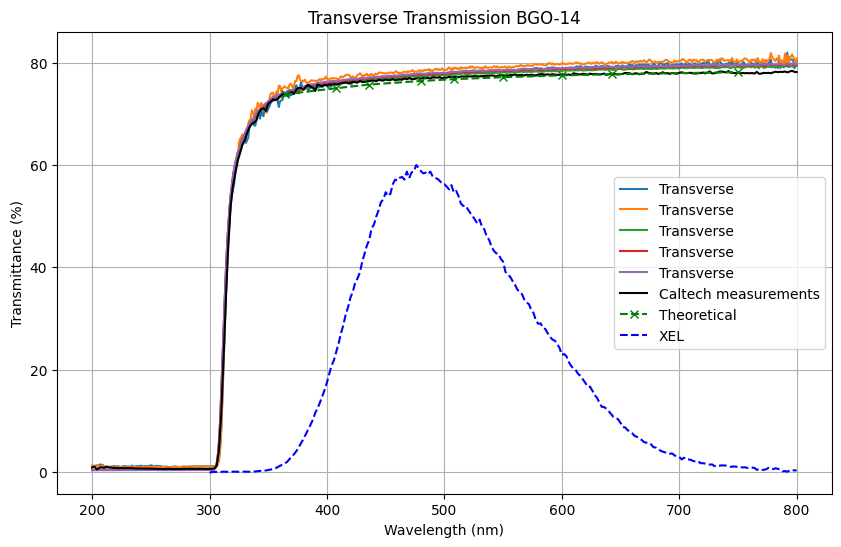

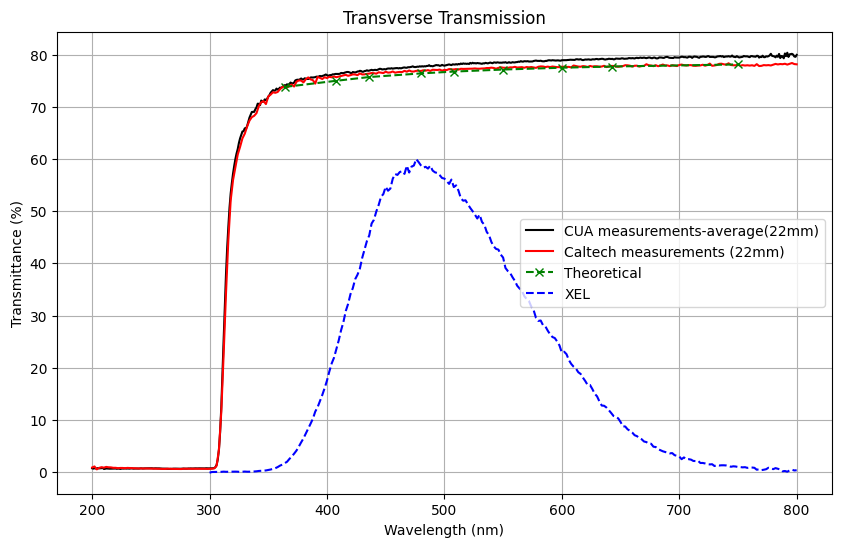

Mean T480 = 77.735
Std Dev = 0.373
SEM = 0.167
CV = 0.48%


In [120]:
#IMPORT PACKAGES
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import pandas as pd
plt.figure(figsize=(10, 6))
#from scipy.signal import find_peaks

Samples_T = [22,23,43,44,49]
# BGO_14_L = [20,21,32,54]
label_14 = ["Transverse", "Transverse", "Transverse", "Transverse", "Transverse",]
BGO_7 = [24,25,26,27]
label_7 = ["Longitudinal", "Longitudinal", "Transverse", "Transverse"]
label_L = ["BGO-14", "BGO-14", "BGO-7", "BGO-7"]
# Samples_T = [22,23,26,27]
label_T = ["BGO-14", "BGO-14", "BGO-7", "BGO-7"]
Tper_L = list(Samples_L)#['1', '2', '3', '4', '5', '6', '7', '8'] #LONGITUDINAL TRANSMISSION PERCENTAGE 
Tper_T = list(Samples_T)#['1', '2', '3','4', '5', '6', '7', '8'] #TRANSVERSE TRANSMISSION PERCENTAGE
Tper_L_at = list(Samples_L)#['1', '2', '3','4', '5', '6', '7', '8']#, '7', '8', '9'] 
Tper_L_at_N =list(Samples_L)# ['1', '2', '3','4', '5', '6', '7', '8']
Tper_T_at = list(Samples_T)#['1', '2', '3','4', '5', '6', '7', '8']
AtLen = list(Samples_T )#['1', '2', '3','4', '5', '6', '7', '8']
#CALTECH readings
#####
lam = [200.0, 202.0, 204.0, 206.0, 208.0, 210.0, 212.0, 214.0, 216.0, 218.0, 220.0, 222.0, 224.0, 226.0, 228.0, 230.0, 232.0, 234.0, 236.0, 238.0, 240.0, 242.0, 244.0, 246.0, 248.0, 250.0, 252.0, 254.0, 256.0, 258.0, 260.0, 262.0, 264.0, 266.0, 268.0, 270.0, 272.0, 274.0, 276.0, 278.0, 280.0, 282.0, 284.0, 286.0, 288.0, 290.0, 292.0, 294.0, 296.0, 298.0, 300.0, 302.0, 304.0, 306.0, 308.0, 310.0, 312.0, 314.0, 316.0, 318.0, 320.0, 322.0, 324.0, 326.0, 328.0, 330.0, 332.0, 334.0, 336.0, 338.0, 340.0, 342.0, 344.0, 346.0, 348.0, 350.0, 352.0, 354.0, 356.0, 358.0, 360.0, 362.0, 364.0, 366.0, 368.0, 370.0, 372.0, 374.0, 376.0, 378.0, 380.0, 382.0, 384.0, 386.0, 388.0, 390.0, 392.0, 394.0, 396.0, 398.0, 400.0, 402.0, 404.0, 406.0, 408.0, 410.0, 412.0, 414.0, 416.0, 418.0, 420.0, 422.0, 424.0, 426.0, 428.0, 430.0, 432.0, 434.0, 436.0, 438.0, 440.0, 442.0, 444.0, 446.0, 448.0, 450.0, 452.0, 454.0, 456.0, 458.0, 460.0, 462.0, 464.0, 466.0, 468.0, 470.0, 472.0, 474.0, 476.0, 478.0, 480.0, 482.0, 484.0, 486.0, 488.0, 490.0, 492.0, 494.0, 496.0, 498.0, 500.0, 502.0, 504.0, 506.0, 508.0, 510.0, 512.0, 514.0, 516.0, 518.0, 520.0, 522.0, 524.0, 526.0, 528.0, 530.0, 532.0, 534.0, 536.0, 538.0, 540.0, 542.0, 544.0, 546.0, 548.0, 550.0, 552.0, 554.0, 556.0, 558.0, 560.0, 562.0, 564.0, 566.0, 568.0, 570.0, 572.0, 574.0, 576.0, 578.0, 580.0, 582.0, 584.0, 586.0, 588.0, 590.0, 592.0, 594.0, 596.0, 598.0, 600.0, 602.0, 604.0, 606.0, 608.0, 610.0, 612.0, 614.0, 616.0, 618.0, 620.0, 622.0, 624.0, 626.0, 628.0, 630.0, 632.0, 634.0, 636.0, 638.0, 640.0, 642.0, 644.0, 646.0, 648.0, 650.0, 652.0, 654.0, 656.0, 658.0, 660.0, 662.0, 664.0, 666.0, 668.0, 670.0, 672.0, 674.0, 676.0, 678.0, 680.0, 682.0, 684.0, 686.0, 688.0, 690.0, 692.0, 694.0, 696.0, 698.0, 700.0, 702.0, 704.0, 706.0, 708.0, 710.0, 712.0, 714.0, 716.0, 718.0, 720.0, 722.0, 724.0, 726.0, 728.0, 730.0, 732.0, 734.0, 736.0, 738.0, 740.0, 742.0, 744.0, 746.0, 748.0, 750.0, 752.0, 754.0, 756.0, 758.0, 760.0, 762.0, 764.0, 766.0, 768.0, 770.0, 772.0, 774.0, 776.0, 778.0, 780.0, 782.0, 784.0, 786.0, 788.0, 790.0, 792.0, 794.0, 796.0, 798.0, 800.0]
Tper_L_14 = [1.21, 1.18, 1.17001, 1.06001, 0.940002, 1.13, 1.03001, 1.09001, 1.02, 1.03001, 0.880005, 0.980011, 0.940002, 0.900009, 0.920013, 0.930008, 0.890015, 0.900009, 0.87001, 0.830002, 0.840011, 0.830002, 0.790008, 0.750015, 0.770004, 0.780014, 0.750015, 0.730011, 0.740005, 0.680008, 0.680008, 0.680008, 0.670013, 0.670013, 0.660004, 0.62001, 0.650009, 0.640015, 0.670013, 0.670013, 0.680008, 0.690002, 0.680008, 0.690002, 0.700012, 0.670013, 0.690002, 0.670013, 0.670013, 0.680008, 0.670013, 0.670013, 0.650009, 0.640015, 0.630005, 0.630005, 0.920013, 2.44, 6.67001, 14.08, 20.56, 26.74, 31.4, 35.37, 39.24, 41.9, 43.98, 46.56, 48.76, 50.52, 51.96, 54.43, 55.88, 56.8, 58.3, 59.88, 60.82, 61.54, 62.4, 63.5, 64.27, 64.89, 65.89, 65.85, 67.16, 67.08, 66.77, 67.87, 67.96, 68.5, 68.46, 69.28, 69.0, 69.22, 69.19, 70.05, 69.9, 69.91, 69.87, 70.23, 70.07, 70.47, 70.62, 70.8, 70.62, 70.97, 70.89, 71.07, 71.23, 71.38, 71.41, 71.53, 71.67, 71.55, 71.76, 71.72, 71.89, 72.05, 71.98, 72.18, 72.38, 72.31, 72.41, 72.31, 72.67, 72.8, 72.8, 72.69, 73.02, 72.95, 73.16, 73.05, 73.02, 73.21, 73.13, 73.31, 73.41, 73.44, 73.42, 73.59, 73.52, 73.67, 73.61, 73.64, 73.74, 73.85, 73.86, 73.72, 74.06, 74.04, 74.09, 74.0, 74.09, 74.22, 74.24, 74.42, 74.49, 74.37, 74.54, 74.34, 74.53, 74.71, 74.5, 74.61, 74.76, 74.71, 74.8, 74.81, 74.8, 74.76, 74.97, 74.91, 74.82, 75.03, 75.0, 75.08, 75.07, 75.23, 75.2, 75.23, 75.23, 75.24, 75.29, 75.26, 75.3, 75.34, 75.33, 75.38, 75.27, 75.38, 75.55, 75.58, 75.61, 75.57, 75.55, 75.52, 75.73, 75.71, 75.63, 75.73, 75.67, 75.63, 75.68, 75.73, 75.9, 75.99, 75.83, 75.77, 76.02, 75.89, 75.99, 75.97, 76.08, 75.97, 75.94, 76.08, 75.91, 76.07, 76.24, 76.13, 76.16, 76.12, 76.13, 76.14, 76.22, 76.16, 76.1, 76.27, 76.22, 76.3, 76.13, 76.3, 76.43, 76.22, 76.3, 76.48, 76.4, 76.43, 76.34, 76.43, 76.53, 76.39, 76.48, 76.44, 76.55, 76.48, 76.32, 76.45, 76.59, 76.62, 76.61, 76.74, 76.57, 76.77, 76.51, 76.7, 76.72, 76.63, 76.76, 76.67, 76.76, 76.81, 76.65, 76.88, 76.57, 76.8, 76.81, 77.16, 77.06, 76.98, 76.92, 76.88, 76.83, 76.76, 76.95, 76.98, 76.75, 77.05, 76.9, 76.79, 77.06, 76.8, 76.69, 77.3, 77.04, 76.8, 76.87, 77.04, 76.93, 76.95, 77.01, 77.17, 77.04, 77.23, 77.16, 77.12, 77.11, 77.11, 77.2, 77.39, 77.25]
Tper_T_14 = [0.86, 1.06001, 0.500015, 0.790008, 0.920013, 0.830002, 0.970001, 0.900009, 0.880005, 0.800003, 0.800003, 0.730011, 0.770004, 0.770004, 0.720001, 0.780014, 0.76001, 0.76001, 0.740005, 0.690002, 0.670013, 0.690002, 0.660004, 0.680008, 0.670013, 0.650009, 0.660004, 0.630005, 0.640015, 0.61, 0.630005, 0.580002, 0.630005, 0.600006, 0.590011, 0.580002, 0.590011, 0.570007, 0.570007, 0.62001, 0.62001, 0.62001, 0.600006, 0.61, 0.62001, 0.600006, 0.62001, 0.62001, 0.61, 0.590011, 0.61, 0.630005, 0.700012, 1.18, 4.28001, 11.57, 22.65, 34.27, 44.52, 52.11, 55.99, 58.45, 60.87, 62.35, 63.98, 64.88, 66.26, 67.38, 68.04, 68.3, 68.82, 70.2, 70.9, 71.11, 70.55, 72.0, 72.36, 72.81, 72.71, 72.87, 73.4, 73.81, 73.94, 73.73, 74.03, 74.28, 73.91, 74.83, 75.08, 75.05, 74.71, 75.31, 75.66, 75.29, 75.14, 74.47, 75.74, 75.57, 75.35, 75.7, 75.54, 75.78, 75.68, 75.83, 75.7, 75.82, 75.92, 76.05, 76.15, 75.97, 76.09, 76.24, 76.22, 76.09, 76.43, 76.23, 76.25, 76.34, 76.39, 76.5, 76.47, 76.38, 76.64, 76.57, 76.5, 76.75, 76.58, 76.62, 76.8, 76.57, 76.66, 76.71, 76.68, 76.92, 76.76, 76.99, 76.79, 76.79, 76.92, 76.95, 76.89, 77.03, 76.95, 77.06, 76.91, 77.13, 77.1, 77.08, 77.16, 76.96, 77.11, 77.07, 77.26, 77.2, 77.18, 77.26, 77.15, 77.32, 77.29, 77.3, 77.33, 77.33, 77.34, 77.38, 77.33, 77.33, 77.37, 77.38, 77.46, 77.46, 77.53, 77.47, 77.33, 77.49, 77.6, 77.52, 77.49, 77.48, 77.59, 77.58, 77.69, 77.55, 77.59, 77.63, 77.51, 77.65, 77.59, 77.65, 77.58, 77.49, 77.7, 77.77, 77.75, 77.64, 77.73, 77.64, 77.75, 77.7, 77.63, 77.64, 77.71, 77.71, 77.65, 77.69, 77.58, 77.94, 77.84, 77.74, 77.71, 77.83, 77.78, 77.66, 77.86, 77.74, 77.8, 77.79, 77.71, 77.75, 77.89, 77.64, 77.74, 77.86, 77.86, 77.75, 77.71, 77.76, 77.83, 78.0, 77.98, 77.91, 77.74, 77.9, 77.91, 77.74, 77.85, 77.87, 78.19, 77.99, 77.94, 77.82, 78.0, 77.81, 77.95, 78.13, 77.94, 77.96, 77.83, 78.0, 77.91, 77.84, 78.04, 78.12, 78.01, 77.94, 78.01, 78.02, 77.9, 77.88, 77.94, 77.96, 78.09, 77.91, 78.03, 78.31, 77.89, 77.95, 78.04, 78.26, 78.29, 78.17, 78.11, 78.37, 78.04, 77.99, 77.98, 78.08, 77.91, 78.01, 77.94, 77.99, 77.93, 77.99, 77.87, 78.2, 77.84, 77.88, 78.02, 77.98, 78.02, 77.95, 78.11, 78.25, 78.15, 78.23, 78.19, 78.28, 78.12, 78.28, 78.42, 78.22, 78.17]
XEL = [-0.23691687052437999, -0.00762072053301521, 0.01851019051683155, 0.017913670793131324, 0.02899613607716523, 0.04473385015125641, 0.10738094131596047, 0.059564840105320045, 0.08160165383510432, 0.11271637850939188, 0.09670654923933839, 0.11315486265843194, 0.08996195319879496, 0.02417437521138407, 0.07502503504349793, 0.13548870437284935, 0.08497879362837343, 0.0886464988620481, 0.14428413922872455, 0.1599862518476523, 0.220193007884818, 0.3290526264366919, 0.3676965717258917, 0.4195133669343379, 0.4938248857111385, 0.6370343880357149, 0.7861770651671794, 0.98695290923196, 1.2088938413272394, 1.5700822646472345, 2.028031644073397, 2.358770923686189, 2.8141447292461206, 3.271222206129937, 4.172617534295824, 4.940818145478804, 5.8496900902490765, 6.832915163534677, 8.102780120978768, 9.469380493666566, 10.758911654012351, 12.29335041197952, 13.792569133890291, 15.418164240582142, 17.016014442359232, 19.29213543245575, 20.690380628712614, 22.629008407295323, 24.613894306548755, 26.80449845377692, 29.219429797811294, 32.12087019809038, 34.6867675101299, 36.542866525514434, 39.30854750554811, 42.046239726683154, 45.2894140114823, 47.92987325264143, 51.42499028844717, 53.7252940074577, 56.82433531605613, 58.758692824663086, 61.60247958848572, 63.058388349855605, 64.97742042824167, 68.43555121101784, 71.05792210380999, 73.79441753796539, 75.61000093380046, 79.39665194913205, 80.61570171869214, 83.25168561195439, 85.31897387663696, 87.92106575487635, 88.82298957031776, 91.1435553522881, 89.88054369522104, 90.59286780229463, 93.70593773990862, 95.2284803589335, 94.93789351214804, 95.86016273444514, 96.11863548124175, 95.27557207795041, 97.85869624914803, 95.70249143939003, 97.59532337720559, 97.93152122287003, 100.0, 99.05292690125773, 97.98275305041382, 97.28712968756919, 97.53187070881346, 96.96917837373238, 97.87676847997668, 96.31915280748883, 95.76165867200808, 95.55030060952122, 94.86127894826319, 93.95246725663644, 93.76201419361301, 92.95279627364371, 92.07575997988924, 93.44675853188137, 91.05921226277482, 91.60710682688791, 89.89569170764425, 87.46052277706758, 86.69692782018595, 86.83674442418693, 85.56548638207275, 84.38385481846942, 83.35904576263573, 82.2310193846088, 81.01188055728306, 82.22940582104933, 79.91077568143402, 79.04314878261209, 76.75398040003182, 75.69488808696633, 73.5050511119506, 72.10739142535438, 71.2887858158727, 71.07353133817288, 69.45766904554014, 68.52596337764822, 65.19944187724701, 64.22072806462857, 63.594909337210964, 62.24221169901035, 61.09079762772928, 59.518273090742305, 58.651484014098074, 57.99061507426249, 56.22219866725054, 55.270981868596515, 54.641282691627225, 52.819741587972, 51.710738505187585, 49.23080217981683, 48.28112850336975, 48.40432865032993, 46.89117562935409, 46.54462389466923, 45.1652558453652, 43.998394465770154, 43.13830523612429, 42.80135022553816, 41.72380332067867, 40.439990740883246, 38.16176425171339, 38.424211377008945, 37.64290758878579, 35.77207198313951, 34.53068480023555, 33.660673109130016, 33.07844304056088, 31.88380912535615, 31.346755939017875, 30.128807859792108, 29.042334812566725, 27.773362506616447, 27.7985749180298, 26.502609729243613, 25.0117489452036, 24.17678596480844, 22.559435868348462, 21.234310420889567, 21.162574044059603, 20.599110187645174, 19.762616757584222, 18.87056602505329, 17.912502504209023, 17.618493653291903, 17.141685337694863, 15.987623619898784, 14.60165795234687, 14.528909156791494, 13.640109131136752, 13.16658804455289, 12.590794762188986, 11.749062278354929, 11.449867347870224, 10.828401445824154, 10.454417558350686, 9.739357791288768, 9.557459116814849, 9.077215117718623, 9.030977541813849, 8.082310150588112, 7.9688902459478514, 7.297542638045426, 6.974283018532672, 6.614956305726128, 6.389528905331521, 6.175853972859936, 5.939299310341248, 6.040750958408523, 5.377755378970642, 5.157983290599015, 4.942631959962852, 4.0888303407458615, 4.652692600009206, 4.056302001758311, 4.094953528109093, 3.949184241420963, 3.525541757814839, 3.492762326594986, 3.5852765307502628, 2.8678025233004405, 2.8842765503226917, 2.729154828201495, 2.4961703376201716, 2.413557249777262, 2.4802292770788132, 1.9058182631985376, 2.197646447712171, 2.076217978089877, 2.1382592782051253, 2.136046968156348, 2.0845846729096995, 1.9313705295160912, 1.667128815196863, 1.8143796943507176, 1.7507499073640156, 1.5997129627676567, 1.5614478205292477, 1.4784149120327619, 1.5320617335733222, 1.315015871221449, 1.4427951286430387, 1.4237851837995283, 1.3361787136074408, 0.7120958435589497, 0.8844046858407509, 0.6020764623753989, 0.7201053267604933, 0.8856132250700339, 1.358077618613442, 1.1190258602487915, 0.9046754285219845, 1.2331105833225124, 1.0111965768115008, 0.8051332696709776, 0.22612832457380838, 0.3089516097273795, 0.09274323971407926, 0.4935630767230801, 0.7082643800654944, 0.49294908003540533, 0.5509818869009722]
XEL_lam = [300.0, 302.0, 304.0, 306.0, 308.0, 310.0, 312.0, 314.0, 316.0, 318.0, 320.0, 322.0, 324.0, 326.0, 328.0, 330.0, 332.0, 334.0, 336.0, 338.0, 340.0, 342.0, 344.0, 346.0, 348.0, 350.0, 352.0, 354.0, 356.0, 358.0, 360.0, 362.0, 364.0, 366.0, 368.0, 370.0, 372.0, 374.0, 376.0, 378.0, 380.0, 382.0, 384.0, 386.0, 388.0, 390.0, 392.0, 394.0, 396.0, 398.0, 400.0, 402.0, 404.0, 406.0, 408.0, 410.0, 412.0, 414.0, 416.0, 418.0, 420.0, 422.0, 424.0, 426.0, 428.0, 430.0, 432.0, 434.0, 436.0, 438.0, 440.0, 442.0, 444.0, 446.0, 448.0, 450.0, 452.0, 454.0, 456.0, 458.0, 460.0, 462.0, 464.0, 466.0, 468.0, 470.0, 472.0, 474.0, 476.0, 478.0, 480.0, 482.0, 484.0, 486.0, 488.0, 490.0, 492.0, 494.0, 496.0, 498.0, 500.0, 502.0, 504.0, 506.0, 508.0, 510.0, 512.0, 514.0, 516.0, 518.0, 520.0, 522.0, 524.0, 526.0, 528.0, 530.0, 532.0, 534.0, 536.0, 538.0, 540.0, 542.0, 544.0, 546.0, 548.0, 550.0, 552.0, 554.0, 556.0, 558.0, 560.0, 562.0, 564.0, 566.0, 568.0, 570.0, 572.0, 574.0, 576.0, 578.0, 580.0, 582.0, 584.0, 586.0, 588.0, 590.0, 592.0, 594.0, 596.0, 598.0, 600.0, 602.0, 604.0, 606.0, 608.0, 610.0, 612.0, 614.0, 616.0, 618.0, 620.0, 622.0, 624.0, 626.0, 628.0, 630.0, 632.0, 634.0, 636.0, 638.0, 640.0, 642.0, 644.0, 646.0, 648.0, 650.0, 652.0, 654.0, 656.0, 658.0, 660.0, 662.0, 664.0, 666.0, 668.0, 670.0, 672.0, 674.0, 676.0, 678.0, 680.0, 682.0, 684.0, 686.0, 688.0, 690.0, 692.0, 694.0, 696.0, 698.0, 700.0, 702.0, 704.0, 706.0, 708.0, 710.0, 712.0, 714.0, 716.0, 718.0, 720.0, 722.0, 724.0, 726.0, 728.0, 730.0, 732.0, 734.0, 736.0, 738.0, 740.0, 742.0, 744.0, 746.0, 748.0, 750.0, 752.0, 754.0, 756.0, 758.0, 760.0, 762.0, 764.0, 766.0, 768.0, 770.0, 772.0, 774.0, 776.0, 778.0, 780.0, 782.0, 784.0, 786.0, 788.0, 790.0, 792.0, 794.0, 796.0, 798.0, 800.0]
#####
# lam_At=list(Range)#['1', '2', '3', '4', '5', '6', '7', '8']
#THEORETICAL DATA
lam_th = [363.9,407.7,435.8,480,508,550,600,643,750]
tran_th = [73.83,75.01,75.73,76.43,76.78,77.17,77.52,77.75,78.15]

L_l = 16 #cm  #LENGTH IN LONGITUDINAL DIRECTION
L_t = 2.2 #cm #LENGTH IN TRANSVERSE DIRECTION
#for i in {1, 2, 3}:

all_TperT = []
T_480_T=[]
j=0
for i,l in zip(list(Samples_T),label_14) : 
    
    
    # Read the file, skipping any header text if needed
    df2 = pd.read_csv('systematics_files/Sample26'+str(i)+'.Sample.Raw.csv', skipinitialspace=True)
    all_TperT.append(df2['%T'].values)   # store each curve
    # Separate columns
    lam1 = df2['nm']
    TperT = df2['%T']
    
    T_480_T.append(TperT[320])
    j += 1
    # Optional: plot
    plt.plot(lam1, TperT, label = f"{l}")
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmittance (%)')
    plt.title('Transverse Transmission BGO-14')
    plt.grid(True)
plt.plot(lam, Tper_T_14, label="Caltech measurements", color = 'black')   
plt.plot(lam_th, tran_th, label = "Theoretical",marker='x',linestyle = "--", color = 'green') 
plt.plot(XEL_lam, np.array(XEL, dtype=float)*0.6, label = "XEL", linestyle = "--", color= 'blue' )
plt.legend()  
# plt.text(0.01, 0.98, f'BGO 14 22x22x160. mm$^3$', fontsize=13, verticalalignment='top', horizontalalignment='left', color='black')
plt.show() 


avg_TperT = np.mean(all_TperT, axis=0)
mask = np.isin(lam1, XEL_lam)
avg_T_reduced_T = avg_TperT[mask]
plt.figure(figsize=(10, 6))
# plt.plot(lam1, avg_TperL, label = "CUA measurements-average(160mm)", color = 'black')
# plt.plot(lam, Tper_L_14, label="Caltech measurements (160mm)", color = 'black', linestyle = "--")  
plt.plot(lam1, avg_TperT, label = "CUA measurements-average(22mm)", color = 'Black')
plt.plot(lam, Tper_T_14, label="Caltech measurements (22mm)", color = 'red')#, linestyle = "--")   

plt.plot(lam_th, tran_th, label = "Theoretical",marker='x',linestyle = "--", color = 'green') 
plt.plot(XEL_lam, np.array(XEL, dtype=float)*0.6, label = "XEL", linestyle = "--", color= 'blue' )
plt.title("Transverse Transmission")
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmittance (%)')
plt.legend()
plt.grid(True)
plt.show()
# for wavelngth 480 nm
######
T_mean = np.mean(T_480_T)
T_std = np.std(T_480_T, ddof=1)   # ddof=1 gives unbiased estimator
T_sem = T_std / np.sqrt(len(T_480_T))
CV = (T_std / T_mean) * 100

print(f"Mean T480 = {T_mean:.3f}")
print(f"Std Dev = {T_std:.3f}")
print(f"SEM = {T_sem:.3f}")
print(f"CV = {CV:.2f}%")
#######


In [117]:
EWLT_L = sum(XEL[i] * avg_T_reduced_T[250-i] for i in range(0, 251)) / sum(XEL[i] for i in range(0, 251))
EWLT_L0 = sum(XEL[i] * Tper_T_14[50+i] for i in range(0, 251)) / sum(XEL[i] for i in range(0, 251))
print(f"EWLT_T= {EWLT_L:.1f}")
print(f"EWLT_T0 = {EWLT_L0:.1f}")

EWLT_T= 77.9
EWLT_T0 = 77.0


2025-10-31: Longitudinal angular deviation along the axxis passing through a corner

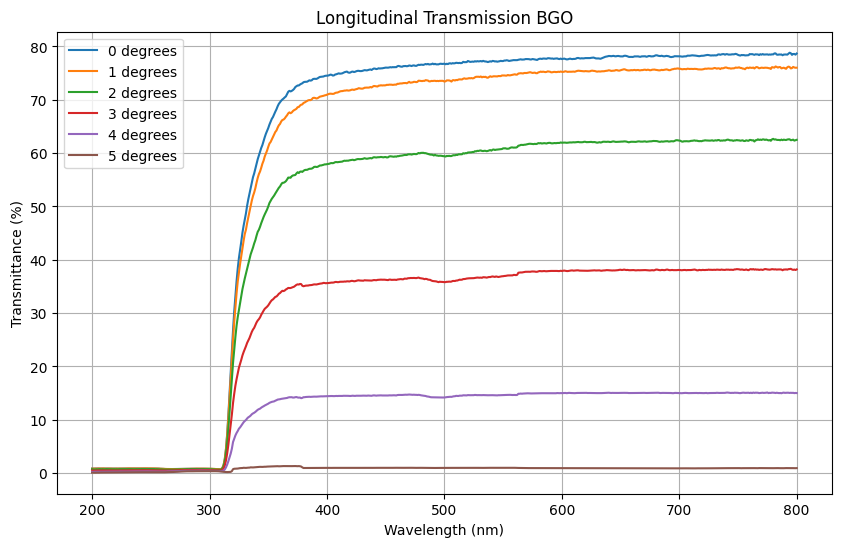

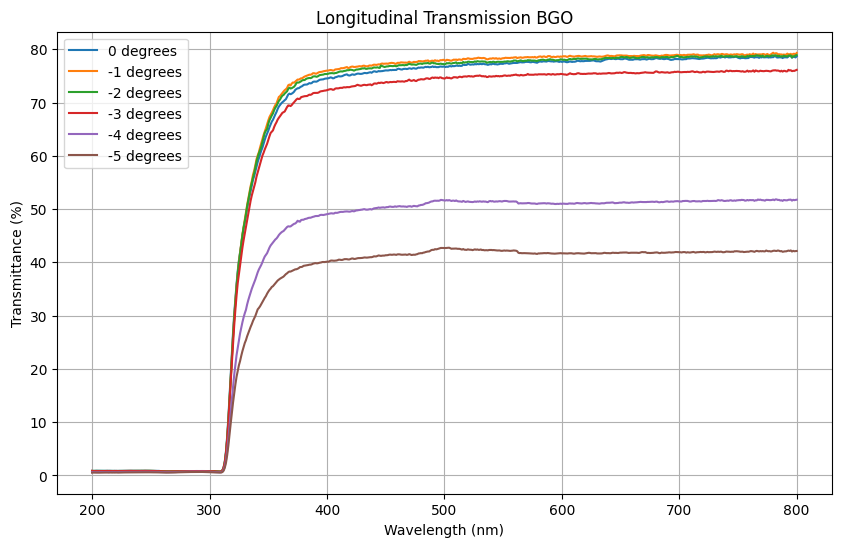

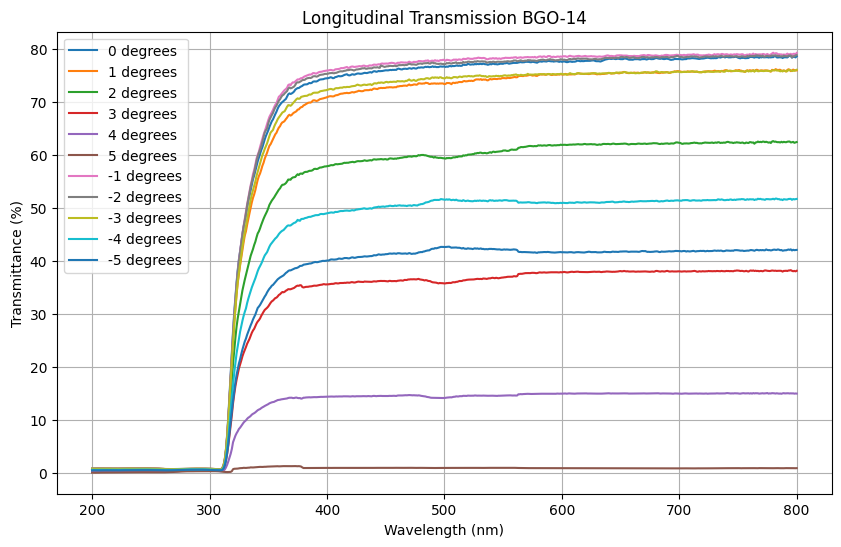

In [80]:

#IMPORT PACKAGES
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import pandas as pd
# plt.figure(figsize=(10, 6))
#from scipy.signal import find_peaks

SamplesP = range(32,38)
label_angleP = ["0","1","2","3", "4","5"]
SamplesN = range(38,43)
label_angleN = ["0","-1", "-2","-3", "-4", "-5"]
Samples = range(32,43)
label_angle = ["0","1","2","3", "4","5", "-1", "-2","-3", "-4", "-5"]
Samples_L = [20,21,24,25]
BGO_14 = [20,21,22,23]
label_14 = ["Longitudinal", "Longitudinal", "Transverse", "Transverse"]
BGO_7 = [24,25,26,27]
label_7 = ["Longitudinal", "Longitudinal", "Transverse", "Transverse"]
label_L = ["BGO-14", "BGO-14", "BGO-7", "BGO-7"]
Samples_T = [22,23,26,27]
label_T = ["BGO-14", "BGO-14", "BGO-7", "BGO-7"]
Tper_L = list(Samples_L)#['1', '2', '3', '4', '5', '6', '7', '8'] #LONGITUDINAL TRANSMISSION PERCENTAGE 
Tper_T = list(Samples_T)#['1', '2', '3','4', '5', '6', '7', '8'] #TRANSVERSE TRANSMISSION PERCENTAGE
Tper_L_at = list(Samples_L)#['1', '2', '3','4', '5', '6', '7', '8']#, '7', '8', '9'] 
Tper_L_at_N =list(Samples_L)# ['1', '2', '3','4', '5', '6', '7', '8']
Tper_T_at = list(Samples_T)#['1', '2', '3','4', '5', '6', '7', '8']
AtLen = list(Samples_T )#['1', '2', '3','4', '5', '6', '7', '8']
lam_At=list(Range)#['1', '2', '3', '4', '5', '6', '7', '8']
#THEORETICAL DATA
lam_th = [363.9,407.7,435.8,480,508,550,600,643,750]
tran_th = [73.83,75.01,75.73,76.43,76.78,77.17,77.52,77.75,78.15]

L_l = 16 #cm  #LENGTH IN LONGITUDINAL DIRECTION
L_t = 2.2 #cm #LENGTH IN TRANSVERSE DIRECTION
#for i in {1, 2, 3}:
plt.figure(figsize=(10, 6))
for i,l in zip(list(SamplesP),label_angleP) : 
    
    
    # Read the file, skipping any header text if needed
    df1 = pd.read_csv('BGO_2025-10-31/Sample26'+str(i)+'.Sample.Raw.csv', skipinitialspace=True)
   
    # Separate columns
    lam1 = df1['nm']
    TperL = df1['%T']
   
    # Optional: plot
    
    plt.plot(lam1, TperL, label = f"{l} degrees")
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmittance (%)')
    plt.title('Longitudinal Transmission BGO')
    plt.grid(True)
    plt.legend()   
plt.show() 
plt.figure(figsize=(10, 6))
for i,l in zip([32]+list(SamplesN),label_angleN) : 
    
    
    # Read the file, skipping any header text if needed
    df1 = pd.read_csv('BGO_2025-10-31/Sample26'+str(i)+'.Sample.Raw.csv', skipinitialspace=True)
   
    # Separate columns
    lam1 = df1['nm']
    TperL = df1['%T']
   
    # Optional: plot
    
    plt.plot(lam1, TperL, label = f"{l} degrees")
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmittance (%)')
    plt.title('Longitudinal Transmission BGO')
    plt.grid(True)
    plt.legend()   
plt.show() 
plt.figure(figsize=(10, 6))
for i,l in zip(list(Samples),label_angle) : 
    
    
    # Read the file, skipping any header text if needed
    df1 = pd.read_csv('BGO_2025-10-31/Sample26'+str(i)+'.Sample.Raw.csv', skipinitialspace=True)
   
    # Separate columns
    lam1 = df1['nm']
    TperL = df1['%T']
   
    # Optional: plot
    
    plt.plot(lam1, TperL, label = f"{l} degrees")
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmittance (%)')
    plt.title('Longitudinal Transmission BGO-14')
    plt.grid(True)
    plt.legend()   
plt.show() 



2025-11-03: Transverse angular deviation along the axis passing through the centre of the crystal

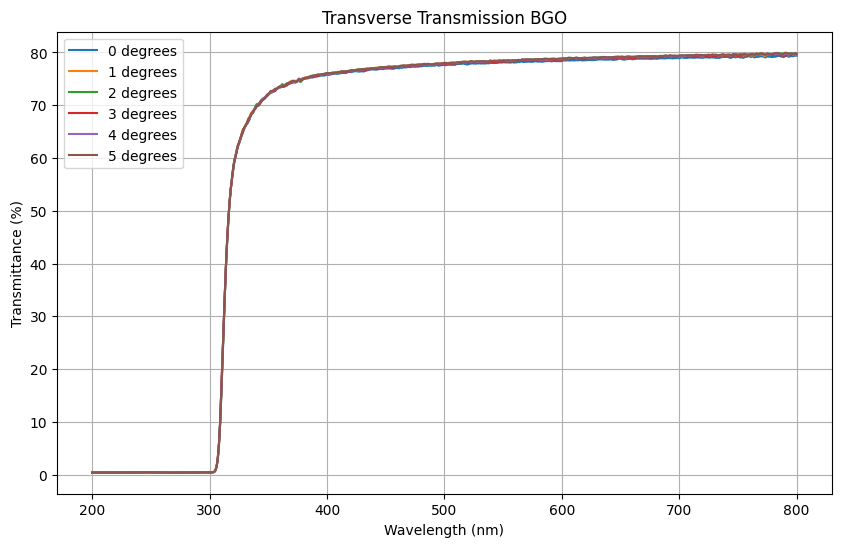

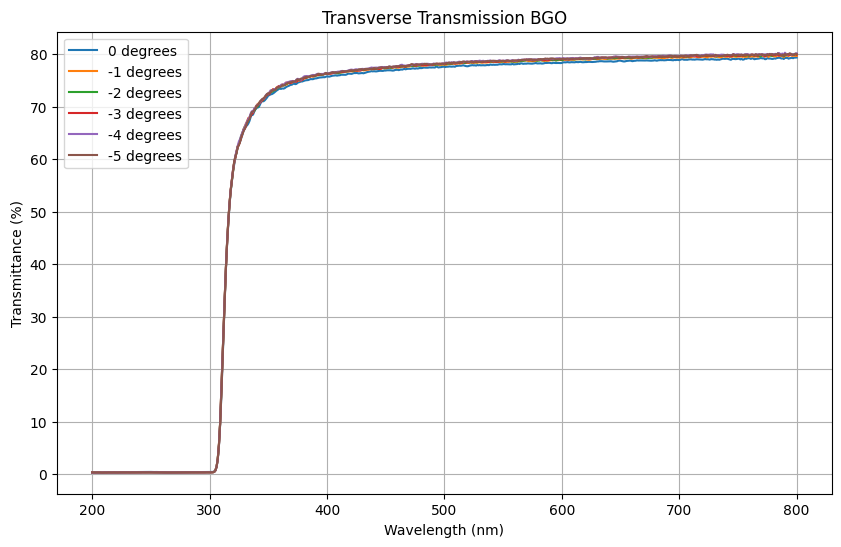

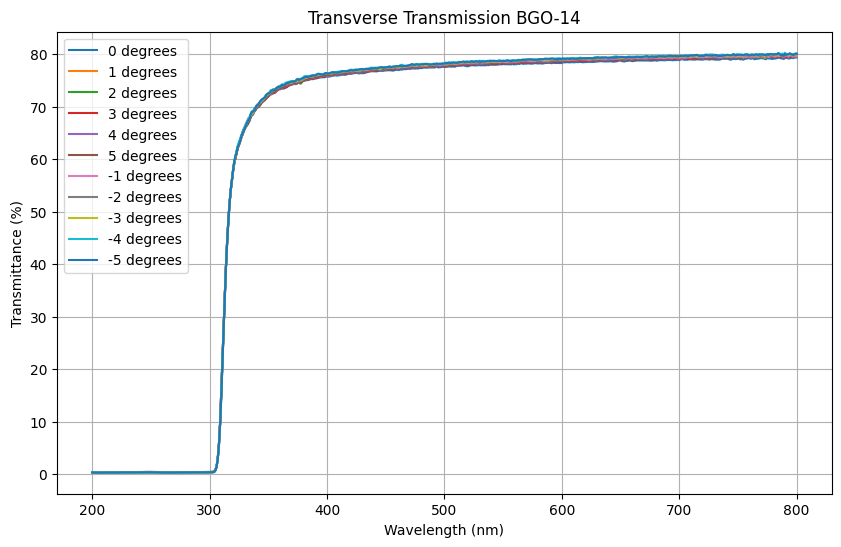

In [82]:
#IMPORT PACKAGES
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import pandas as pd
# plt.figure(figsize=(10, 6))
#from scipy.signal import find_peaks

SamplesP = range(43,49)
label_angleP = ["0","1","2","3", "4","5"]
SamplesN = range(49,54)
label_angleN = ["0","-1", "-2","-3", "-4", "-5"]
Samples = range(43,54)
label_angle = ["0","1","2","3", "4","5", "-1", "-2","-3", "-4", "-5"]
Samples_L = [20,21,24,25]
BGO_14 = [20,21,22,23]
label_14 = ["Longitudinal", "Longitudinal", "Transverse", "Transverse"]
BGO_7 = [24,25,26,27]
label_7 = ["Longitudinal", "Longitudinal", "Transverse", "Transverse"]
label_L = ["BGO-14", "BGO-14", "BGO-7", "BGO-7"]
Samples_T = [22,23,26,27]
label_T = ["BGO-14", "BGO-14", "BGO-7", "BGO-7"]
Tper_L = list(Samples_L)#['1', '2', '3', '4', '5', '6', '7', '8'] #LONGITUDINAL TRANSMISSION PERCENTAGE 
Tper_T = list(Samples_T)#['1', '2', '3','4', '5', '6', '7', '8'] #TRANSVERSE TRANSMISSION PERCENTAGE
Tper_L_at = list(Samples_L)#['1', '2', '3','4', '5', '6', '7', '8']#, '7', '8', '9'] 
Tper_L_at_N =list(Samples_L)# ['1', '2', '3','4', '5', '6', '7', '8']
Tper_T_at = list(Samples_T)#['1', '2', '3','4', '5', '6', '7', '8']
AtLen = list(Samples_T )#['1', '2', '3','4', '5', '6', '7', '8']
lam_At=list(Range)#['1', '2', '3', '4', '5', '6', '7', '8']
#THEORETICAL DATA
lam_th = [363.9,407.7,435.8,480,508,550,600,643,750]
tran_th = [73.83,75.01,75.73,76.43,76.78,77.17,77.52,77.75,78.15]

L_l = 16 #cm  #LENGTH IN LONGITUDINAL DIRECTION
L_t = 2.2 #cm #LENGTH IN TRANSVERSE DIRECTION
#for i in {1, 2, 3}:
plt.figure(figsize=(10, 6))
for i,l in zip(list(SamplesP),label_angleP) : 
    
    
    # Read the file, skipping any header text if needed
    df1 = pd.read_csv('BGO_2025-11-03/Sample26'+str(i)+'.Sample.Raw.csv', skipinitialspace=True)
   
    # Separate columns
    lam1 = df1['nm']
    TperL = df1['%T']
   
    # Optional: plot
    
    plt.plot(lam1, TperL, label = f"{l} degrees")
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmittance (%)')
    plt.title('Transverse Transmission BGO')
    plt.grid(True)
    plt.legend()   
plt.show() 
plt.figure(figsize=(10, 6))
for i,l in zip([43]+list(SamplesN),label_angleN) : 
    
    
    # Read the file, skipping any header text if needed
    df1 = pd.read_csv('BGO_2025-11-03/Sample26'+str(i)+'.Sample.Raw.csv', skipinitialspace=True)
   
    # Separate columns
    lam1 = df1['nm']
    TperL = df1['%T']
   
    # Optional: plot
    
    plt.plot(lam1, TperL, label = f"{l} degrees")
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmittance (%)')
    plt.title('Transverse Transmission BGO')
    plt.grid(True)
    plt.legend()   
plt.show() 

plt.figure(figsize=(10, 6))
for i,l in zip(list(Samples),label_angle) : 
    
    
    # Read the file, skipping any header text if needed
    df1 = pd.read_csv('BGO_2025-11-03/Sample26'+str(i)+'.Sample.Raw.csv', skipinitialspace=True)
   
    # Separate columns
    lam1 = df1['nm']
    TperL = df1['%T']
   
    # Optional: plot
    
    plt.plot(lam1, TperL, label = f"{l} degrees")
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmittance (%)')
    plt.title('Transverse Transmission BGO-14')
    plt.grid(True)
    plt.legend()   
plt.show() 



2025-11-07: Longitudinal angular deviation along the axis passing through centre of crystal

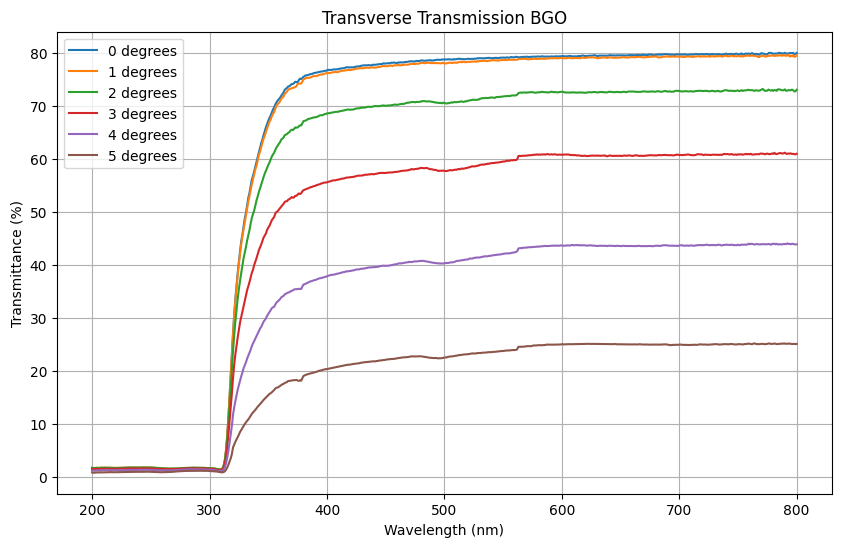

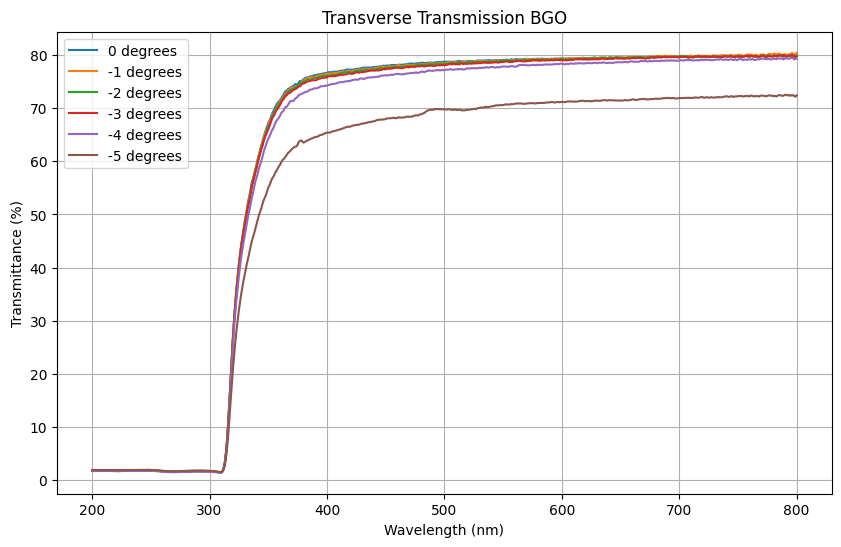

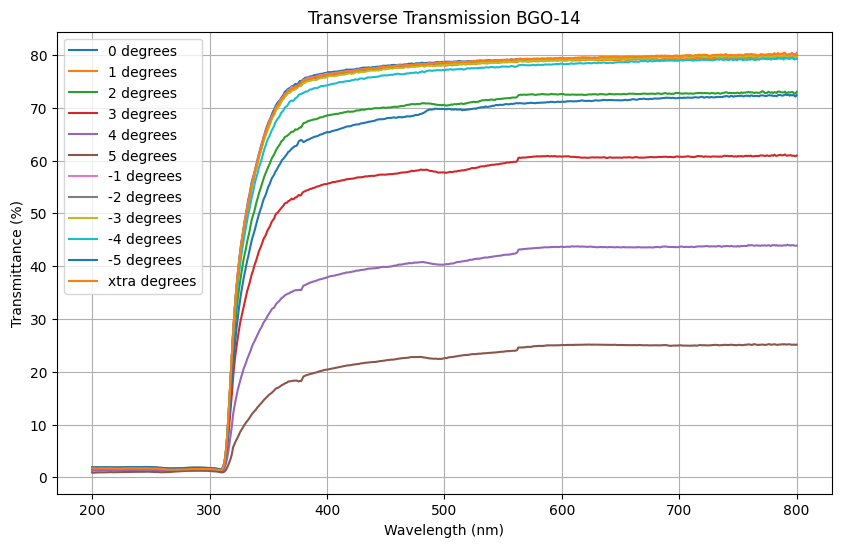

In [ ]:
#IMPORT PACKAGES
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import pandas as pd
# plt.figure(figsize=(10, 6))
#from scipy.signal import find_peaks

SamplesP = range(54,60)
label_angleP = ["0","1","2","3", "4","5"]
SamplesN = range(60,65)
label_angleN = ["0","-1", "-2","-3", "-4", "-5"]
Samples = range(54,66)
label_angle = ["0","1","2","3", "4","5", "-1", "-2","-3", "-4", "-5","xtra"]
Samples_L = [20,21,24,25]
BGO_14 = [20,21,22,23]
label_14 = ["Longitudinal", "Longitudinal", "Transverse", "Transverse"]
BGO_7 = [24,25,26,27]
label_7 = ["Longitudinal", "Longitudinal", "Transverse", "Transverse"]
label_L = ["BGO-14", "BGO-14", "BGO-7", "BGO-7"] 
Samples_T = [22,23,26,27]
label_T = ["BGO-14", "BGO-14", "BGO-7", "BGO-7"]
Tper_L = list(Samples_L)#['1', '2', '3', '4', '5', '6', '7', '8'] #LONGITUDINAL TRANSMISSION PERCENTAGE 
Tper_T = list(Samples_T)#['1', '2', '3','4', '5', '6', '7', '8'] #TRANSVERSE TRANSMISSION PERCENTAGE
Tper_L_at = list(Samples_L)#['1', '2', '3','4', '5', '6', '7', '8']#, '7', '8', '9'] 
Tper_L_at_N =list(Samples_L)# ['1', '2', '3','4', '5', '6', '7', '8']
Tper_T_at = list(Samples_T)#['1', '2', '3','4', '5', '6', '7', '8']
AtLen = list(Samples_T )#['1', '2', '3','4', '5', '6', '7', '8']
lam_At=list(Range)#['1', '2', '3', '4', '5', '6', '7', '8']
#THEORETICAL DATA
lam_th = [363.9,407.7,435.8,480,508,550,600,643,750]
tran_th = [73.83,75.01,75.73,76.43,76.78,77.17,77.52,77.75,78.15]

L_l = 16 #cm  #LENGTH IN LONGITUDINAL DIRECTION
L_t = 2.2 #cm #LENGTH IN TRANSVERSE DIRECTION
#for i in {1, 2, 3}:
plt.figure(figsize=(10, 6))
for i,l in zip(list(SamplesP),label_angleP) : 
    
    
    # Read the file, skipping any header text if needed
    df1 = pd.read_csv('BGO_2025-11-07/Sample26'+str(i)+'.Sample.Raw.csv', skipinitialspace=True)
   
    # Separate columns
    lam1 = df1['nm']
    TperL = df1['%T']
   
    # Optional: plot
    
    plt.plot(lam1, TperL, label = f"{l} degrees")
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmittance (%)')
    plt.title('Transverse Transmission BGO')
    plt.grid(True)
    plt.legend()   
plt.show() 
plt.figure(figsize=(10, 6))
for i,l in zip([54]+list(SamplesN),label_angleN) : 
    
    
    # Read the file, skipping any header text if needed
    df1 = pd.read_csv('BGO_2025-11-07/Sample26'+str(i)+'.Sample.Raw.csv', skipinitialspace=True)
   
    # Separate columns
    lam1 = df1['nm']
    TperL = df1['%T']
   
    # Optional: plot
    
    plt.plot(lam1, TperL, label = f"{l} degrees")
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmittance (%)')
    plt.title('Transverse Transmission BGO')
    plt.grid(True)
    plt.legend()   
plt.show() 

plt.figure(figsize=(10, 6))
for i,l in zip(list(Samples),label_angle) : 
    
    
    # Read the file, skipping any header text if needed
    df1 = pd.read_csv('BGO_2025-11-07/Sample26'+str(i)+'.Sample.Raw.csv', skipinitialspace=True)
   
    # Separate columns
    lam1 = df1['nm']
    TperL = df1['%T']
   
    # Optional: plot
    
    plt.plot(lam1, TperL, label = f"{l} degrees")
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmittance (%)')
    plt.title('Transverse Transmission BGO-14')
    plt.grid(True)
    plt.legend()   
plt.show() 



In [ ]:
#IMPORT PACKAGES
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import pandas as pd
#from scipy.signal import find_peaks

# INITIALISE REQUIRED LISTS AND VARIABLES
# lam = np.linspace(200,800,301) #WAVELENGTH SPAN
# #lam_at = np.linspace(300,520,111) #wavelength for attenuation length calculation
# lam_at = np.linspace(400,700,151) # REDUCED WAVLENGTH RANGE FOR THE CACULATION OF ATTENNUATION LENGTH
# Tper_L = ['1', '2', '3']#, '4', '5', '6']
# Tper_L_N = ['1', '2', '3']#,'4', '5', '6']
# Tper_T = ['1', '2', '3']#,'4', '5', '6']
# Tper_L_at = ['1', '2', '3']#,'4', '5', '6']
# Tper_L_at_N = ['1', '2', '3']#,'4', '5', '6']
# Tper_T_at = ['1', '2', '3']#,'4', '5', '6']
# AtLen = ['1', '2', '3']#,'4', '5', '6']
# lam_At=['1', '2', '3']#, '4', '5', '6']
Tper_L = list(range(0, 21))#['1', '2', '3', '4', '5', '6', '7', '8'] #LONGITUDINAL TRANSMISSION PERCENTAGE 
#Tper_L_N = list(range(1, 21))#['1', '2', '3','4', '5', '6', '7', '8'] #LONGITUDINAL TRANSMISSION PERCENTAGE- NORMALISED
Tper_T = list(range(1, 21))#['1', '2', '3','4', '5', '6', '7', '8'] #TRANSVERSE TRANSMISSION PERCENTAGE
Tper_L_at = list(range(1, 21))#['1', '2', '3','4', '5', '6', '7', '8']#, '7', '8', '9'] 
Tper_L_at_N =list(range(1, 21))# ['1', '2', '3','4', '5', '6', '7', '8']
Tper_T_at = list(range(1, 21))#['1', '2', '3','4', '5', '6', '7', '8']
AtLen = list(range(1, 21))#['1', '2', '3','4', '5', '6', '7', '8']
lam_At=list(range(1, 21))#['1', '2', '3', '4', '5', '6', '7', '8']
#THEORETICAL DATA
lam_th = [363.9,407.7,435.8,480,508,550,600,643,750]
tran_th = [73.83,75.01,75.73,76.43,76.78,77.17,77.52,77.75,78.15]

L_l = 16 #cm  #LENGTH IN LONGITUDINAL DIRECTION
L_t = 2.2 #cm #LENGTH IN TRANSVERSE DIRECTION
#for i in {1, 2, 3}:

for i in list(range(0,8)): # For all 20 crystals
    #
    Tper_L[i-1] = []
    Tper_L_at[i-1] = []
    #print(Tper_L[1])
    Tper_T[i-1] = []
    Tper_T_at[i-1] = []
    AtLen[i-1] = []

    
    # Read the file, skipping any header text if needed
    df = pd.read_csv('BGO_2025-09-23/Sample262'+str(i)+'.Sample.Raw.csv', skipinitialspace=True)

    # Separate columns
    Tper_L[i-1] = df['nm']
    Tper_T[i-1] = df['%T']

    # Optional: plot
    import matplotlib.pyplot as plt
    plt.plot(x, y)
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmittance (%)')
    plt.title('Longitudinal Transmission BGO')
    plt.grid(True)
    plt.legend()   
    plt.show() 
    #TRANSVERSE TRANSMISSION

    
                    
    #LONGITUDINAL TRANSMISSION
    
    with open('B'+str(i)+'LT3.ASP', 'r') as file:           #OPEN FILES AND STORE THE TRANSMISSION DATA IN RESPECTIVE LIST
        for line_number, line in enumerate(file, start=1):
            if 7 <= line_number < 308:
            #if line_number >= 7 and line_number < 258:
                line =line.strip()
                try:
                # print(lin)
                    perL = float(line.strip())
             #       print(line_number, line)
                    Tper_L[i-1].append(perL)
                except ValueError:
                    print(f"skipping invalid line: {line}")
                    continue 

        # # Normalize with respect to transmission if applicable
        # if Tper_T[i-1][300] < Tper_L[i-1][300]:
        #     for j in list(range(301)):
        #         Tper_L_N[i-1][j] = Tper_L[i-1][j]*Tper_T[i-1][300] / Tper_L[i-1][300]
            
                    
        # else:
        #     Tper_L_N[i-1] = Tper_L[i-1]
                
                
    #FOR ATTENUATION
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    #TRANNSVERSE 

    with open('B'+str(i)+'TT3.ASP', 'r') as file:#kya hua
        for line_number, line in enumerate(file, start=1):
            #if line_number >= 57 and line_number < 168:
            if line_number >= 107 and line_number < 258: #index numbers corresponds to lambda = 400 and 702 nm.
                line =line.strip()
                try:
                # print(lin)
                    perT_at = float(line.strip())
             #       print(line_number, line)
                    Tper_T_at[i-1].append(perT_at)


                except ValueError:
                    print(f"skipping invalid line: {line}")
    
    
    #LONGITUDINAL
    Tper_L_at_N[i-1]= []
    
    
    
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
    # #Storing without Normalization                  
    
    # with open('B'+str(i)+'LT3.ASP', 'r') as file:
    #     for line_number, line in enumerate(file, start=1):
    #         #if line_number >= 57 and line_number < 168:
    #         if line_number >= 107 and line_number < 258:#index numbers corresponds to lambda = 400 and 702 nm.
    #             line =line.strip()
    #             try:
    #             # print(lin)
    #                 perL_at = float(line.strip())
    #          #       print(line_number, line)
    #                 #if perL_at < Tper_T_at[i-1][line_number-107]:
    #                 Tper_L_at_N[i-1].append(perL_at)
    #                 #else:
                        

    #             except ValueError:
    #                 print(f"skipping invalid line: {line}")
    #             #print(line_number)
    #     print("Stored without normalization") 
        
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
    
    #NORMALIZATION WRT THE FIRST INTERSECTION
    
    with open('B'+str(i)+'LT3.ASP', 'r') as file:
        for line_number, line in enumerate(file, start=1):
            #if line_number >= 57 and line_number < 168:
            #print(line_number)
            if line_number >= 107 and line_number < 258:#index numbers corresponds to lambda = 400 and 702 nm.
                line = line.strip()
                ln=line_number
                try:
                # print(lin)
                    #print(line)
                    perL_at = float(line.strip())
                    # print(ln)
                    # print(perL_at)
                    # print(Tper_T_at[i-1][ln-107])
                    #print(line_number, line)
                    if perL_at < Tper_T_at[i-1][ln-107]:
                        Tper_L_at[i-1].append(perL_at)
                    else:
                        #print(line_number)
                        Tper_L_at[i-1].append(perL_at)
                        break
                    #print(line_number)   
                except ValueError:
                    print(f"skipping invalid line: {line}")
                
          
    norm_index = ln-107     
    print(norm_index)        
    with open('B'+str(i)+'LT3.ASP', 'r') as file: 
        #print(norm_index)
        if perL_at > Tper_T_at[i-1][norm_index]:
            
           
            for line_number, line_N in enumerate(file, start=1):
            #if line_number >= 57 and line_number < 168:
                if line_number >= 107 and line_number < 258:#index numbers corresponds to lambda = 400 and 702 nm.
                    line_N =line_N.strip()
                    
                    try:
                        if norm_index != 7:
                            perL_at_N = float(line_N.strip())* Tper_T_at[i-1][norm_index]/Tper_L_at[i-1][norm_index]
                            Tper_L_at_N[i-1].append(perL_at_N)
                        else:
                            perL_at_N = float(line_N.strip())
                    #print(line_number)   
                    except ValueError:
                       # print("here")
                        print(f"skipping invalid line: {line}")
        else: 
            Tper_L_at_N[i-1] = Tper_L_at[i-1]
    print("Stored with first incidence normalization")             
    #print(Tper_L_at[i-1])
    
    
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
    # #NORMALIZATION WRT THE TRANSVERSE TRANSMITTANCE AT 800 NM

    # with open('B'+str(i)+'LT3.ASP', 'r') as file:
    #     for line_number, line in enumerate(file, start=1):
    #         #if line_number >= 57 and line_number < 168:
    #         if line_number >= 107 and line_number < 258:#index numbers corresponds to lambda = 400 and 702 nm.
    #             line =line.strip()
    #             try:
    #             # print(lin)
    #                 #print(line)
    #                 perL_at = float(line.strip())
    #         #       print(line_number, line)
    #                 if Tper_T[i-1][300] < Tper_L[i-1][300]: #Comparing Longitudinal and transverse Transmittance at 800nm
    #                     Tper_L_at_N[i-1].append(perL_at*Tper_T[i-1][300]/Tper_L[i-1][300])
    #                 else:
    #                     Tper_L_at_N[i-1].append(perL_at)
    #                 #print(line_number)   
    #             except ValueError:
    #                 print(f"skipping invalid line: {line}")
    # print("Stored with transverse transmittence @ 800nm normalization")  
           
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
    # Assigning attenuation length values
    lam_At[i-1] = []
    #AtLen[i-1] = []


    m=0
    for t, l in zip(Tper_T_at[i-1], Tper_L_at_N[i-1]):
        if l < t:
            lam_At[i-1].append(float(lam_at[m]))
            value = (L_l - L_t)/math.log(t / l)
            AtLen[i-1].append(value)
            m=m+1
        else:
            print(str(lam_at[m])+ "nm is the cutoff")
            break
    #print(i)    
    #print(AtLen[i-1])
    
    if len(lam_At[i-1]) < lam_At[0].index(470):
        Mes = "can not be found for this wavelength"
    else:
        Mes1 = AtLen[i-1][lam_At[i-1].index(470)]
        if len(lam_At[i-1]) < lam_At[0].index(470):
            Mes= "{:.2f}".format(Mes1)
        else:
            Mes2= AtLen[i-1][lam_At[i-1].index(470)]
            Mes = "{:.2f}".format(np.mean([Mes1, Mes2]))
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
#--------------------------------------------------------------------------------------------------------------------------------------------------------
    # Plot on the first subplot (ax1)
    ax1.plot(lam, Tper_L[i-1], label='Longitudinal(16cm)', color = 'black')
    ax1.plot(lam, Tper_T[i-1], label='Transverse(2.2cm)', color = 'red')
    ax1.plot(lam_th, tran_th, label='Theoretical', color = 'green', marker =  'x')
    ax1.set_ylabel('Transmission (%)')
    ax1.set_title(f'Transmittance BGO ({i})')
    ax1.grid(True)
    ax1.legend()

    # Plot on the second subplot (ax2)
    ax2.plot(lam_At[i-1], AtLen[i-1], label='Attenuation Length (cm)', linestyle='--')
    ax2.set_xlabel('Wavelength (nm)')
    ax2.set_ylabel('Attenuation Length (cm)')
   # ax2.set_ylim(0,2000)
    ax2.grid(True)
    ax2.text(0.0, 0.8, f'Attenuation Length(470nm)={Mes}cm', transform=ax2.transAxes, fontsize=11, verticalalignment='top')
    ax2.legend()
    
    #plt.tight_layout()
    
    
    
    #print(AtLength[i-1])   


    plt.savefig("BGOT" + str(i) + ".png", format="png")
#print(AtLength[4])
#print(Tper)
#print(Tper_L)
plt.show()
plt.ion()
print("Transmissions executed successfully")

FileNotFoundError: [Errno 2] No such file or directory: '/BGO_2025-09-23/Sample2620.Sample.Raw.csv'

In [1]:
lam_th

NameError: name 'lam_th' is not defined

/var/folders/np/1nk6dbzn3dn79swcw81d2rkm0000gn/T/ipykernel_5560/3087263138.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


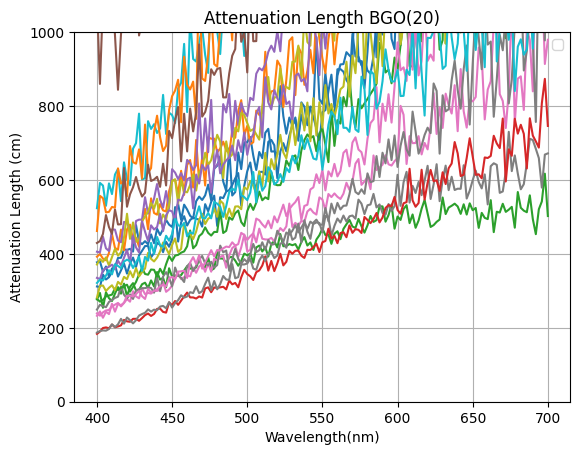

In [17]:
for m in list(range(1,21)):
    plt.figure(1)
    #plt.plot(lam, Tper_L[i-1], label = 'Longitudinal(16cm)')  
    #plt.plot(lam, Tper_T[i-1], label = 'Transverse(2.2cm)')
    #plt.figure(6+i)
    plt.plot(lam_At[m-1], AtLen[m-1])#, label = 'Attenuation Length (cm)'+str(m))
    plt.xlabel('Wavelength(nm)')
    plt.ylabel('Attenuation Length (cm)')
    plt.title('Attenuation Length BGO(' + str(i)+')' )
    plt.grid(True)
    plt.legend()
#print(Tper)
#print(Tper_L)
plt.ylim(0,1000)
plt.show()
plt.ion()

#NORMALIZATION WRT THE FIRST INTERSECTION

[Try using different code snippets to plot attenuation length. keep trhem in the same file as a complete code so u can run it each time . that means do proper intialization of all variables each time. Wtite your concerns about using different methods]


 and try to make sense about which approach is best according to you. Next important step is to figure out a way to store the data in root so it is easily accesible , perhaps using wavelength markers rather than index markers. again think how it might have been done for mat budget.
Keep this note dont delete yet. might be useful for writing in github repo.

[I like the plot above. HSows how i understand python a little and can adjust the data i wanna focus on, Try focusinng on a partivular area even idf ur data is going out of that particular x or y range.]


Once done with this and understand the party of storing data in root using youtube tutorials plot and fit for XEL. and also for decay time however the data for that is small but still
Also plot XEL and transmission together

Do not think tooo much if cant figure out. either ask discuss or check papers

IMPORT PACKAGES

In [ ]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math

DEFINE VARIABLES

In [9]:
#p= Tper_L.tolist()
print(Tper_T)

[[0.840011, 0.920013, 0.960007, 0.87001, 0.87001, 0.840011, 0.750015, 0.750015, 0.800003, 0.770004, 0.750015, 0.780014, 0.700012, 0.710007, 0.730011, 0.710007, 0.710007, 0.710007, 0.690002, 0.670013, 0.680008, 0.650009, 0.650009, 0.640015, 0.630005, 0.62001, 0.61, 0.600006, 0.580002, 0.540008, 0.570007, 0.550003, 0.540008, 0.520004, 0.530014, 0.540008, 0.530014, 0.550003, 0.540008, 0.550003, 0.540008, 0.580002, 0.570007, 0.560013, 0.530014, 0.560013, 0.550003, 0.560013, 0.560013, 0.540008, 0.550003, 0.540008, 0.62001, 1.04, 3.8, 9.87001, 19.22, 29.38, 38.48, 45.22, 49.16, 52.06, 54.63, 56.94, 58.2, 60.06, 62.1, 62.78, 64.52, 65.55, 66.4, 66.83, 67.31, 68.6, 69.34, 69.63, 70.47, 69.79, 70.47, 70.65, 71.2, 71.98, 72.3, 72.11, 72.32, 73.01, 72.91, 73.12, 72.99, 73.54, 73.39, 73.54, 73.26, 73.93, 74.14, 73.35, 73.88, 74.01, 74.08, 74.22, 74.31, 74.28, 74.57, 74.56, 74.75, 74.57, 74.74, 74.89, 74.97, 74.73, 75.04, 74.95, 75.15, 75.17, 75.3, 75.32, 75.47, 75.31, 75.61, 75.47, 75.38, 75.66, 7

All TRANSMISSION

/var/folders/np/1nk6dbzn3dn79swcw81d2rkm0000gn/T/ipykernel_762/3680243253.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


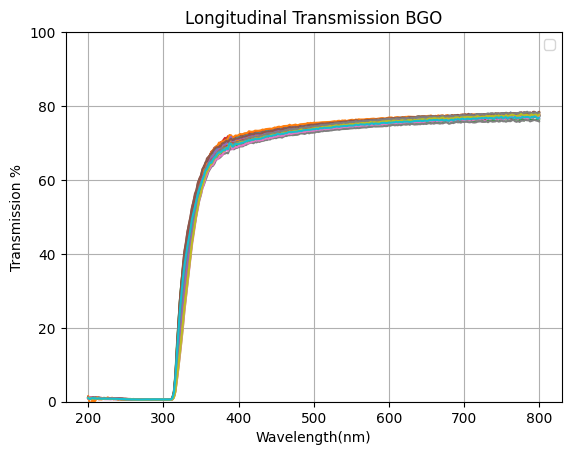

In [22]:
for m in list(range(1,21)):
    plt.figure(1)
    #plt.plot(lam, Tper_L[i-1], label = 'Longitudinal(16cm)')  
    #plt.plot(lam, Tper_T[i-1], label = 'Transverse(2.2cm)')
    #plt.figure(6+i)
    #plt.plot(lam, Tper_T[m-1])
    plt.plot(lam, Tper_L[m-1])# label = f'Transmittance BGO ({i})')#, label = 'Attenuation Length (cm)'+str(m))
    plt.xlabel('Wavelength(nm)')
    plt.ylabel('Transmission %')
    plt.title('Longitudinal Transmission BGO')
    plt.grid(True)
    plt.legend()
#print(Tper)
#plt.bar_label("hello")
#print(Tper_L)
#plt.xlim(700,800)
plt.ylim(0,100)
plt.show()
plt.ion()

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


/var/folders/np/1nk6dbzn3dn79swcw81d2rkm0000gn/T/ipykernel_762/2796927350.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


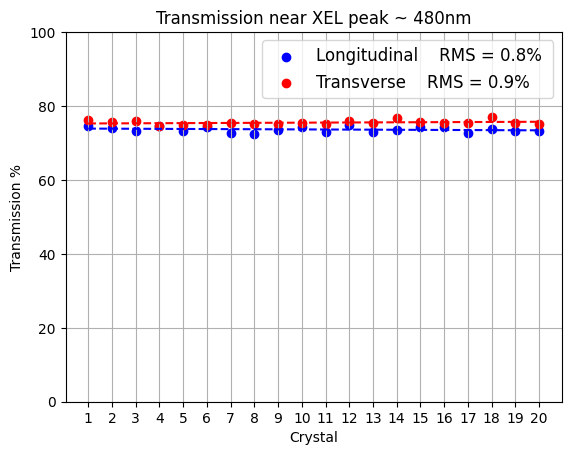

In [79]:
Crystal = list(range(1,21))
TL = [0] * 20 
TT = [0] * 20 
for m in Crystal:
    print(m)
    TL[m-1]=(Tper_L[m-1][140])
    TT[m-1]=(Tper_T[m-1][140])


# Calculate RMS values for each normalized dataset
def calculate_rms(data):
    return np.sqrt(np.mean((data - np.mean(data))**2))

rms_T = calculate_rms(TL)*100/np.mean(TL)
rms_L = calculate_rms(TT)*100/np.mean(TT)


# Plot data and fits for LO_1
#plt.errorbar(Crystal, TL, yerr= sigma_LO_1, fmt='o', markerfacecolor='none', markeredgecolor='red', label='Data')
#plt.plot(position_fit, fit_func(position_fit, *popt_T), color='black', linestyle='--', label=f'Fit: Transmission = Trans + delta')

# plt.text(8, 70, f'Longitudinal    RMS = {rms_L:.1f}% ', fontsize=14, verticalalignment='top')
# plt.text(8, 60, f'Transverse    RMS = {rms_T:.1f}% ', fontsize=14, verticalalignment='top')


plt.xlabel('Crystal')
plt.ylabel('Transmission %')
plt.title('Transmission near XEL peak ~ 480nm')
#plt.hist(TL, bins=1, edgecolor='black')
plt.grid(True)
plt.legend()
plt.ylim(0,100)
plt.scatter(Crystal, TL, color='blue', label=f'Longitudinal    RMS = {rms_L:.1f}% ', marker='o')
plt.scatter(Crystal, TT, color='red', label=f'Transverse    RMS = {rms_T:.1f}% ', marker='o')
coefficients = np.polyfit(Crystal, TL, 1)  # Fit a first-degree polynomial (linear trend)
polynomial = np.poly1d(coefficients)  # Get the polynomial object to evaluate the trend line
trend_line = polynomial(Crystal)  # Compute the trend line values

coefficientsT = np.polyfit(Crystal, TT, 1)  # Fit a first-degree polynomial (linear trend)
polynomialT = np.poly1d(coefficientsT)  # Get the polynomial object to evaluate the trend line
trend_lineT = polynomialT(Crystal)  # Compute the trend line values

# Plot the trend line
plt.plot(Crystal, trend_line, color='blue', linestyle='--')
plt.plot(Crystal, trend_lineT, color='red', linestyle='--')
plt.legend(fontsize =12)
plt.xticks(Crystal)
plt.show()



In [56]:
print(TL)


[74.61, 74.05, 73.3, 74.66, 73.2, 74.25, 72.8, 72.33, 73.61, 74.28, 73.04, 74.88, 73.11, 73.52, 74.28, 74.36, 72.84, 73.67, 73.3, 73.21]


In [49]:
TL[0]

IndexError: list index out of range